In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd
import numpy as np

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

analysis_directory = TemporaryDirectory()
repacked_counts_path = Path(analysis_directory.name) / 'counts.zarr'
analysis_path = Path(analysis_directory.name) / 'data_organization.zarr'
repack_store(
    f'{dataset}/data.zarr',
    str(repacked_counts_path),
    nthreads=2,
)
ds = scarf.mount_datastore(
    str(repacked_counts_path),
    at=str(analysis_path),
    default_assay='RNA',
    nthreads=4,
)

analysis_run = ds.pipeline.run(
    filtering=False,
    hvg_count=500,
    pca_dims=15,
    umap=False,
    leiden={'partitions': [0.5]},
    cell_cycle=False,
    paris=False,
    doublets=False,
    markers=True,
)
cell_selection = analysis_run['analysis_cell_selection']
hvg_ref = analysis_run['highly_variable_features']
normalized = analysis_run['normalized']
clusters_ref = analysis_run['clusters']
marker_ref = analysis_run['markers']

ds

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/artifacts/neighbors//distances: 1 / 1 complete

Repacking RNA/artifacts/neighbors//indices: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

...

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Finding markers: 2 / 2 complete

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_percentRibo', 
            'RNA_percentMito', 'X_umap1', 'RNA_nFeatures', 'RNA_clusters', 'clusters_coarse', 
            'RNA_nCounts', 'clusters', 'RNA_leiden_cluster', 'S_score', 'RNA_UMAP1', 
            'X_umap2', 'RNA_UMAP2'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'highly_variable_genes', 'dropOuts', 
            'I__hvgs', 'nCells'

In [3]:
cluster_values = np.asarray(ds.load_artifact(clusters_ref)['values'][:])
pd.Series(cluster_values).value_counts().sort_index()

1     246
2     678
3     583
4     464
5      19
6     516
7      91
8     325
9     445
10    130
11    199
Name: count, dtype: int64

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── artifacts
│   └── featureData
├── artifacts
│   ├── cell_selection
│   └── metadata_snapshot
├── cellData
│   ├── G2M_score (3696,) float32
│   ├── I (3696,) bool
│   ├── RNA_UMAP1 (3696,) float32
│   ├── RNA_UMAP2 (3696,) float32
│   ├── RNA_clusters (3696,) int64
│   ├── RNA_leiden_cluster (3696,) int64
│   ├── RNA_nCounts (3696,) float64
│   ├── RNA_nFeatures (3696,) float64
│   ├── RNA_percentMito (3696,) float64
│   ├── RNA_percentRibo (3696,) float64
│   ├── S_score (3696,) float32
│   ├── X_umap1 (3696,) float32
│   ├── X_umap2 (3696,) float32
│   ├── clusters (3696,) <U13
│   ├── clusters_coarse (3696,) <U13
│   ├── ids (3696,) <U16
│   └── names (3696,) <U16
└── pipeline
    └── runs



In [5]:
ds.show_zarr_tree(start='cellData')

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_clusters (3696,) int64
├── RNA_leiden_cluster (3696,) int64
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── X_umap1 (3696,) float32
├── X_umap2 (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U16
└── names (3696,) <U16

  X_umap1: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_percentMito: shape=(3696,), dtype=float64, chunks=(100000,)
  clusters_coarse: shape=(3696,), dtype=<U13, chunks=(100000,)
  G2M_score: shape=(3696,), dtype=float32, chunks=(100000,)
  I: shape=(3696,), dtype=bool, chunks=(100000,)
  names: shape=(3696,), dtype=<U16, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_nC

In [6]:
ds.cells.to_pandas_dataframe(['I'])['I'].value_counts()

I
True    3696
Name: count, dtype: int64

In [7]:
ds.show_zarr_tree(start='RNA', depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── cluster_selection
│   ├── connectivity_map
│   ├── feature_scaling
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   ├── metadata_snapshot
│   ├── neighbors
│   ├── normalized
│   └── reduction
└── featureData
    ├── I (27998,) bool
    ├── I__hvgs (27998,) bool
    ├── dropOuts (27998,) int64
    ├── highly_variable_genes (27998,) <U5
    ├── ids (27998,) <U15
    ├── nCells (27998,) int64
    └── names (27998,) <U15



In [8]:
ds.show_zarr_tree(start='RNA/featureData', depth=1)

/RNA/featureData
├── I (27998,) bool
├── I__hvgs (27998,) bool
├── dropOuts (27998,) int64
├── highly_variable_genes (27998,) <U5
├── ids (27998,) <U15
├── nCells (27998,) int64
└── names (27998,) <U15

  highly_variable_genes: shape=(27998,), dtype=<U5, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  I__hvgs: shape=(27998,), dtype=bool, chunks=(100000,)
  ids: shape=(27998,), dtype=<U15, chunks=(100000,)
  nCells: shape=(27998,), dtype=int64, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int64, chunks=(100000,)
  names: shape=(27998,), dtype=<U15, chunks=(100000,)


In [9]:
ds.show_zarr_tree(start='RNA/artifacts', depth=1)

/RNA/artifacts
├── ann_index
│   └── 20c36e41e7c3550337361c7ef9a3d2b6aa9a72f47b92994f7d15d9b1ffa8b2f2
├── cluster_labels
│   └── 731d0a6c3c38435408629d2c289ff2220bd762734bf536db1900f04c31aeb06d
├── cluster_selection
│   └── cff501d889b1b64c65040c5ce2ea5f7ff41af7f2e4db0fea4b322d4cd756d643
├── connectivity_map
│   └── 9e6132ae8d884579bd7661b98364b4a3e0e904e5e9d7a1ac4e58a9c6f14f0e1a
├── feature_scaling
│   └── fe53bbe2efc14aac6069b7539b2691bfe79f4e3fc13e6bc2fe8641db86bfe0d6
├── feature_selection
│   ├── dc9bd5ab5545e6710dd02fb6def838a11fb4ff73402f412070cb099c5f86efce
│   └── fb1d9985ec107688d46a76db3325619e0cb7135bf60e028eae9063a6c4e33241
├── feature_summary
│   └── d8fb0bc0fd922223a35d2624ed6700b2b0b0e76933c458596ef6e594e15d8c19
├── marker_table
│   └── c7cc469739ee4faaa71f1ba6ee5f707ae416a2bb02d51a9a2578de2bfad1cc30
├── metadata_snapshot
│   └── 136c8230febb0e4d668a25905cd6359ee8abe579d61bedfb927d93cce3fa84b6
├── neighbors
│   └── 068d17a77e95d88f58b576e8a9060ee58166e3f98c1db255b8ed22a4

In [10]:
ds.cells.head()

,I,ids,names,RNA_nFeatures,RNA_percentMito,RNA_clusters,RNA_nCounts,clusters_coarse,G2M_score,X_umap1,X_umap2,RNA_percentRibo,RNA_leiden_cluster,RNA_UMAP2,clusters,RNA_UMAP1,S_score
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,2356.0,0.706500,5,4954.0,Pre-endocrine,-0.252071,6.143066,-0.063644,15.563181,5,5.158421,Pre-endocrine,-22.176723,-0.224902
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,2613.0,1.286947,1,7071.0,Ductal,-0.232610,-9.906417,0.197778,30.632160,1,-4.812334,Ductal,13.041407,-0.014707
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,1984.0,0.687961,5,4070.0,Endocrine,-0.286834,7.559791,0.583762,19.041769,5,-4.607774,Alpha,-26.320560,-0.171255
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,2860.0,1.195886,6,8362.0,Ductal,0.191243,-11.283765,4.218998,28.653432,6,-22.613249,Ductal,12.318944,0.599244
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,2211.0,1.094310,7,5026.0,Ngn3 high EP,-0.126030,1.721565,-4.753407,19.419021,7,24.942205,Ngn3 high EP,-7.786273,-0.179981


In [11]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs,highly_variable_genes
0,True,Xkr4,Xkr4,6,3690,False,False
1,True,Gm37381,Gm37381,0,3696,False,
2,True,Rp1,Rp1,0,3696,False,
3,True,Rp1-1,Rp1-1,0,3696,False,
4,True,Sox17,Sox17,0,3696,False,


In [12]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'RNA_nCounts', 'RNA_nFeatures', 'clusters']
).set_index('ids')

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [13]:
cluster_labels = ds.cells.fetch('clusters')
first_cluster = str(cluster_labels[0])
is_first_cluster = cluster_labels.astype(str) == first_cluster
ds.cells.insert(column_name='is_first_cluster', values=is_first_cluster, overwrite=True)

In [14]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'clusters', 'is_first_cluster']
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


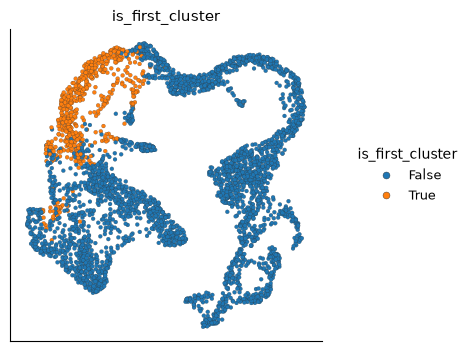

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='is_first_cluster',
)

In [16]:
i_backup = ds.cells.fetch_all('I').copy()
ds.cells.update_key(is_first_cluster, 'I')

print(
    'fetch:', ds.cells.fetch('clusters').shape,
    'fetch_all:', ds.cells.fetch_all('clusters').shape,
)
ds.cells.to_pandas_dataframe(['I'])['I'].value_counts()

fetch: (592,) fetch_all: (3696,)


I
False    3104
True      592
Name: count, dtype: int64

In [17]:
ds.cells.insert(column_name='I', values=i_backup, overwrite=True, force=True)
print('Restored active cells:', int(ds.cells.fetch_all('I').sum()))

Restored active cells: 3696


In [18]:
try:
    ds.cells.insert(
        column_name='is_first_cluster',
        values=is_first_cluster,
    )
except ValueError:
    print("Expected validation: use overwrite=True to replace an existing column.")

Expected validation: use overwrite=True to replace an existing column.


In [19]:
active_before = int(ds.cells.fetch_all('I').sum())
count_range = ds.cells.sift(
    'RNA_nCounts',
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=['RNA_nCounts', 'RNA_nFeatures'],
    lows=[1000, 500],
    highs=[15000, 4000],
)
cluster_rows = ds.cells.get_index_by([first_cluster], 'clusters')

print(
    'count_range:', int(count_range.sum()),
    'joint_range:', int(joint_range.sum()),
    'cluster_rows:', int(cluster_rows.size),
)
print('Active cells (I) before:', active_before)
print('Active cells (I) after:', int(ds.cells.fetch_all('I').sum()))

count_range: 3669 joint_range: 3667 cluster_rows: 592
Active cells (I) before: 3696


Active cells (I) after: 3696


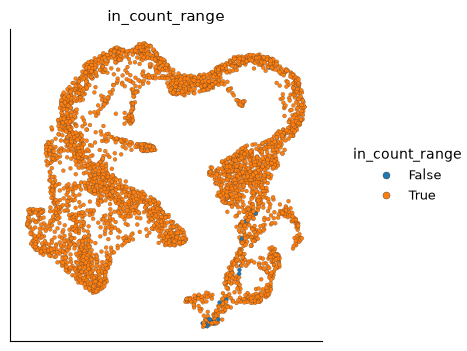

In [20]:
ds.cells.insert(column_name='in_count_range', values=count_range, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='in_count_range',
)

In [21]:
ds.RNA.rawData

ChunkedArray(shape=(3696, 27998), dtype=uint16, chunksize=(3696, 27998), numblocks=1)

In [22]:
ds.RNA.normed()

ChunkedArray(shape=(3696, 27998), dtype=float64, chunksize=(3696, 27998), numblocks=1)

In [23]:
print('Raw shape:', ds.RNA.rawData.shape)
print('Normed shape:', ds.RNA.normed().shape)
ds.RNA.rawData[:3, :5].compute()

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint16)

In [24]:
ds.RNA.normed()[:3, :5].compute()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [25]:
print('Current method:', ds.RNA.normMethod.__name__)

Current method: norm_lib_size


In [26]:
reused_normalized = ds.run_normalization(cell_selection, hvg_ref)
print('Reused:', reused_normalized == normalized)
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='6bc2fe13a0c4...')

In [27]:
status = ds.inspect_artifact(reused_normalized)
print('Complete:', status.complete)
print('Operation:', status.operation)
print('Parameters:', status.parameters)

group = ds.load_artifact(reused_normalized)
print('Arrays:', list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['feature_squared_sum', 'feature_sum', 'data']


In [28]:
ds.get_markers(
    marker=marker_ref,
    group_id=cluster_values[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,Mnx1,17638,0.46353,0.23270,0.02892,0.60163,0.09159,8.04694,1.839654e-124,0.76023,5.150664e-120
1,1,Aard,8350,0.38767,0.16568,0.02447,0.32114,0.07101,6.77043,9.171069e-43,0.62811,4.012056e-40
2,1,Prss50,26005,0.38041,0.10646,0.01946,0.35772,0.07478,5.47203,2.166227e-50,0.64373,1.479269e-47
3,1,Amigo2,8139,0.36290,0.12426,0.02407,0.42683,0.09681,5.16305,3.937047e-56,0.66898,3.801015e-53
4,1,Lmo1,21859,0.33791,0.04632,0.00734,0.19106,0.04203,6.30851,1.457208e-25,0.57657,2.266607e-23


Aggregating marker values per group: 1 / 1 complete

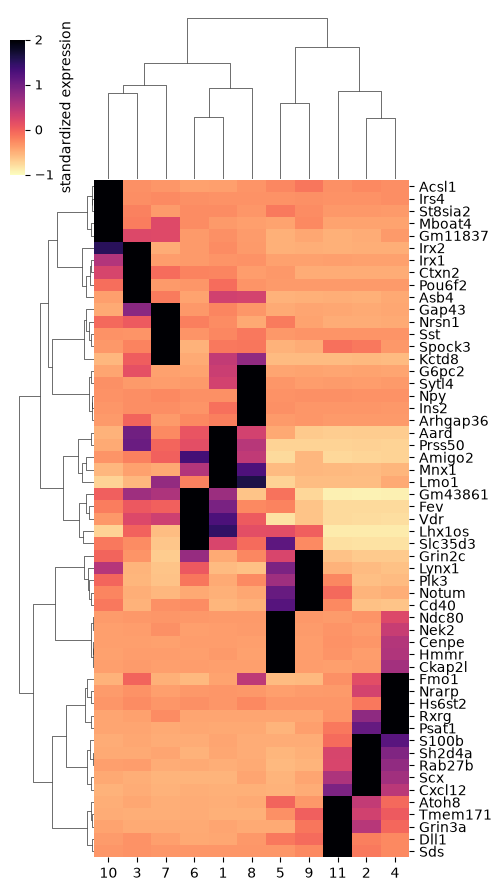

In [29]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    topn=5,
    figsize=(5, 9),
)

In [30]:
markers_csv = 'scarf_datasets/pancreas_cluster_markers.csv'
ds.export_markers_to_csv(
    marker=marker_ref,
    csv_filename=markers_csv,
    min_score=0.1,
    min_frac_exp=0.1,
)
pd.read_csv(markers_csv).iloc[:5, :6]

,1,10,11,2,3,4
0,Mnx1,Mboat4,Grin3a,S100b,Irx1,Nrarp
1,Aard,St8sia2,Dll1,Cxcl12,Ctxn2,Hs6st2
2,Prss50,Irs4,Atoh8,Sh2d4a,Pou6f2,Psat1
3,Amigo2,Gm11837,Sds,Rab27b,Irx2,Rxrg
4,Lmo1,Acsl1,Tmem171,Scx,Asb4,Fmo1
